# Geiger-Mueller Dose Calibration – Step-by-Step Procedure

This notebook walks through the estimation of the dose-calculation registers
for the Geiger-Mueller probe firmware.  Starting from a raw CPS vs dose-rate
calibration table, we:

1. Load and inspect the calibration data
2. Segment the data into two CPS ranges (P1, P2) separated by a threshold
3. Fit a quadratic polynomial to each segment independently
4. Encode the floating-point coefficients into the firmware's `mantissa × 10^exponent` int16 register format
5. Verify the reconstruction quality

In [13]:
%config InlineBackend.figure_formats = ["svg"]
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve() / "src"))

import numpy as np
import matplotlib.pyplot as plt

from nlab_modbus.calibration import (
    load_calibration_csv,
    fit_piecewise_quadratic,
    fit_residuals,
    encode_mantissa_exp,
    decode_mantissa_exp,
)

# Consistent plot colours
C_P1   = "#2577b4"   # blue  – P1 segment
C_P2   = "#e07b39"   # orange – P2 segment
C_EXCL = "#999999"   # gray  – excluded (above dose limit)
C_TH   = "crimson"   # threshold line
C_DL   = "#8b008b"   # dose-limit line (dark magenta)
C_FW   = "#444444"   # firmware reconstruction (dark gray)

## Configuration

In [14]:
# Path to a CSV with 'x' (CPS) and 'y' (dose rate) columns.
# None → bundled default calibration for a generic GM tube.
CSV_PATH = None

# Fixed split point between P1 and P2 polynomial segments.
THRESHOLD_CPS = 200

# Maximum rated dose rate from the GM tube manufacturer's datasheet.
# Points above this value are excluded from the P2 fit (dead-time saturation).
DOSE_LIMIT = 3000.0   # µSv/h

# CSV column names (only relevant for custom CSVs).
X_COL = "counts"
Y_COL = "dose"

## Step 1 – Load calibration data

In [15]:
x, y = load_calibration_csv(CSV_PATH, x_col=X_COL, y_col=Y_COL)

print(f"Source      : {'bundled default' if CSV_PATH is None else CSV_PATH}")
print(f"Data points : {len(x)}")
print(f"CPS range   : {x.min():.4g}  –  {x.max():.4g}")
print(f"Dose range  : {y.min():.4g}  –  {y.max():.4g} µSv/h")

Source      : bundled default
Data points : 211
CPS range   : 0.5561  –  1.951e+04
Dose range  : 0.01032  –  8.093e+04 µSv/h


## Step 2 – Inspect the raw calibration curve

The raw data maps the detector's pulse rate (counts per second) to a
reference dose rate.  Note the saturation region at high CPS where the
GM tube's dead time causes the response to flatten or roll off.

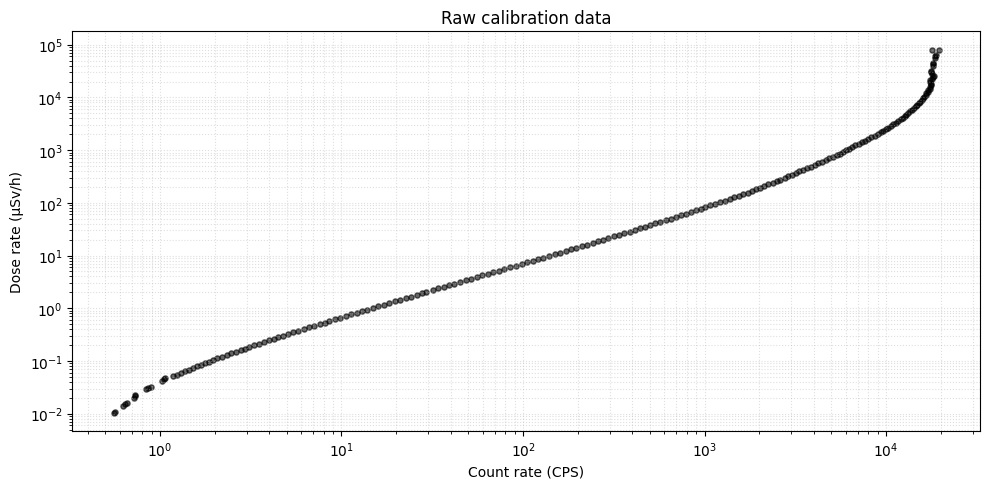

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x, y, s=14, color="black", alpha=0.6)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Count rate (CPS)")
ax.set_ylabel("Dose rate (µSv/h)")
ax.set_title("Raw calibration data")
ax.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()
plt.show()

## Step 3 – Segment the data

The firmware converts CPS to dose rate using a **piecewise quadratic** –
two independent second-order polynomials, each valid on its own CPS range,
joined at a **threshold** $T$:

$$
\text{dose}(CPS) = \begin{cases}
a_2^{(1)} \cdot CPS^2 + a_1^{(1)} \cdot CPS + a_0^{(1)}
  & \text{if } CPS \leq T \\
a_2^{(2)} \cdot CPS^2 + a_1^{(2)} \cdot CPS + a_0^{(2)}
  & \text{if } CPS > T
\end{cases}
$$

### Threshold

The threshold is fixed at $T = 200$ CPS — a split point that separates
the low-rate and high-rate operating regions of the GM tube.

### Dose limit

The GM tube's maximum rated dose rate from the manufacturer's datasheet is
**3 000 µSv/h**.  Above this value, dead-time saturation causes the
response to flatten or roll off.  The **DOSE_LIMIT** excludes these
saturated points from the P2 fit:

$$
\text{P2 data} = \lbrace (CPS_i, y_i) \mid CPS_i > T \text{ and } y_i < \text{DOSE\_LIMIT} \rbrace
$$

Threshold   : 200 CPS
Dose limit  : 3000 µSv/h
P1 points   : 94
P2 points   : 75
Excluded    : 42


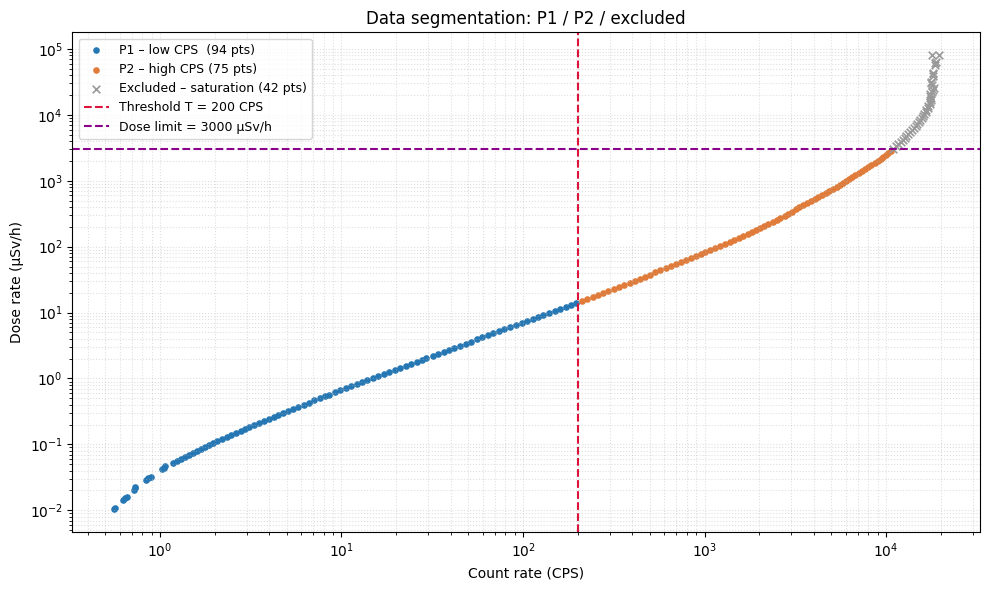

In [17]:
threshold = float(THRESHOLD_CPS)

# ── Build masks ───────────────────────────────────────────────────────────────
low      = x <= threshold
high     = (x > threshold) & (y < DOSE_LIMIT)
excluded = (x > threshold) & (y >= DOSE_LIMIT)

print(f"Threshold   : {threshold:.0f} CPS")
print(f"Dose limit  : {DOSE_LIMIT:.0f} µSv/h")
print(f"P1 points   : {low.sum()}")
print(f"P2 points   : {high.sum()}")
print(f"Excluded    : {excluded.sum()}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x[low],      y[low],      s=14, color=C_P1,   label=f"P1 – low CPS  ({low.sum()} pts)")
ax.scatter(x[high],     y[high],     s=14, color=C_P2,   label=f"P2 – high CPS ({high.sum()} pts)")
ax.scatter(x[excluded], y[excluded], s=30, color=C_EXCL,  marker="x", linewidths=1.2,
           label=f"Excluded – saturation ({excluded.sum()} pts)")

ax.axvline(threshold,  color=C_TH, lw=1.5, ls="--", label=f"Threshold T = {threshold:.0f} CPS")
ax.axhline(DOSE_LIMIT, color=C_DL, lw=1.5, ls="--", label=f"Dose limit = {DOSE_LIMIT:.0f} µSv/h")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Count rate (CPS)")
ax.set_ylabel("Dose rate (µSv/h)")
ax.set_title("Data segmentation: P1 / P2 / excluded")
ax.legend(fontsize=9)
ax.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()
plt.show()

## Step 4 – Fit the low-CPS polynomial (P1)

For the points where $CPS \leq T$ we fit:

$$\text{dose}_{P1}(CPS) = a_2^{(1)} \cdot CPS^2 + a_1^{(1)} \cdot CPS + a_0^{(1)}$$

The fit uses **weighted least squares** with weights $w_i = 1\,/\,|y_i|$
to equalise the *relative* error across the wide dynamic range
(without weighting, the large dose-rate values at the upper end of each
segment would dominate the residual sum).

P1 coefficients (float64):
  a₂ =    +1.8149119338e-05
  a₁ =    +6.8783884542e-02
  a₀ =    -2.8622736000e-02

  dose_P1(CPS) = 1.8149e-05 · CPS²  +  6.8784e-02 · CPS  +  -2.8623e-02


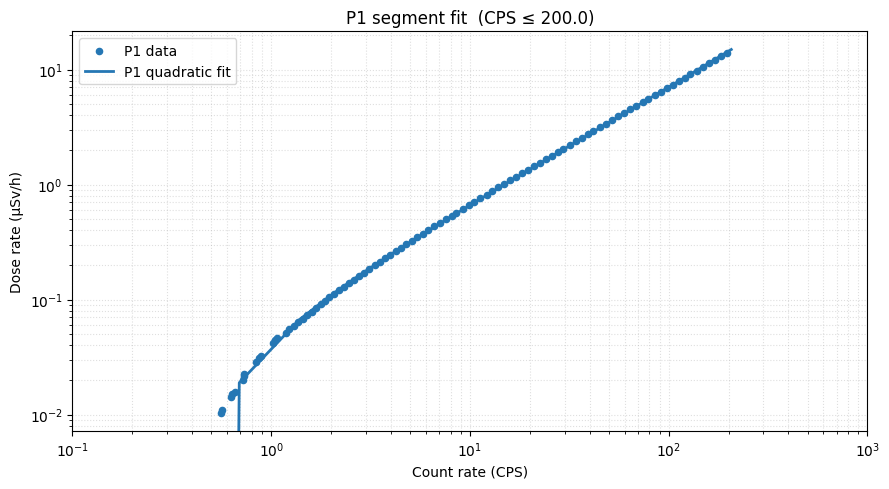

In [18]:
w_low = 1.0 / np.abs(y[low])
p1 = np.polyfit(x[low], y[low], 2, w=w_low)   # [a2, a1, a0]

print("P1 coefficients (float64):")
print(f"  a₂ = {p1[0]:>+20.10e}")
print(f"  a₁ = {p1[1]:>+20.10e}")
print(f"  a₀ = {p1[2]:>+20.10e}")
print(f"\n  dose_P1(CPS) = {p1[0]:.4e} · CPS²  +  {p1[1]:.4e} · CPS  +  {p1[2]:.4e}")

# Dense evaluation grid for the P1 range
x_p1_grid = np.linspace(0, x[low].max() * 1.05, 300)
x_p1_grid[0] = max(x_p1_grid[0], 1e-6)  # avoid log(0)
y_p1_grid = np.polyval(p1, x_p1_grid)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x[low], y[low], s=20, color=C_P1, zorder=3, label="P1 data")
ax.plot(x_p1_grid, y_p1_grid, color=C_P1, lw=2, label="P1 quadratic fit")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 1e3)
ax.set_xlabel("Count rate (CPS)")
ax.set_ylabel("Dose rate (µSv/h)")
ax.set_title(f"P1 segment fit  (CPS ≤ {threshold:.1f})")
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()
plt.show()

## Step 5 – Fit the high-CPS polynomial (P2)

For the points where $CPS > T$ **and** $y < \text{DOSE\_LIMIT}$ we fit:

$$\text{dose}_{P2}(CPS) = a_2^{(2)} \cdot CPS^2 + a_1^{(2)} \cdot CPS + a_0^{(2)}$$

Same inverse-$y$ weighting as P1.  Points above the dose limit (saturation
region) are **not** used for fitting.

P2 coefficients (float64):
  a₂ =    +1.7732208492e-05
  a₁ =    +6.0292493466e-02
  a₀ =    +2.1827058279e+00

  dose_P2(CPS) = 1.7732e-05 · CPS²  +  6.0292e-02 · CPS  +  2.1827e+00


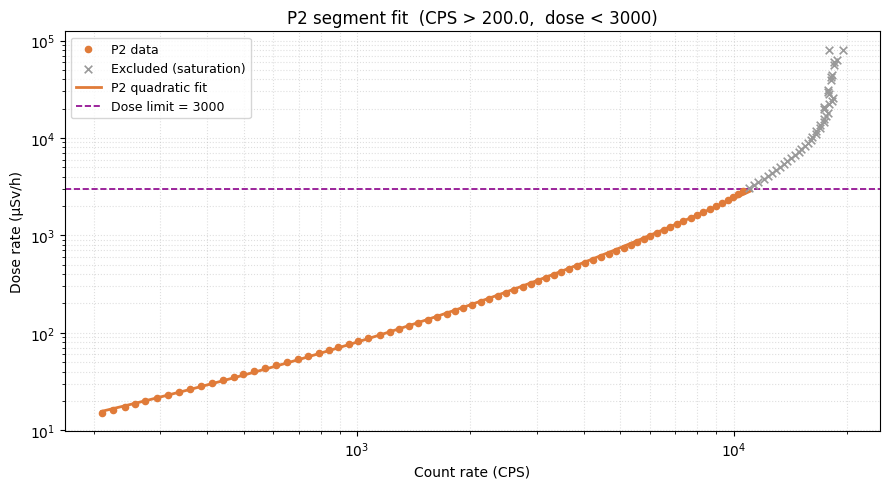

In [19]:
w_high = 1.0 / np.abs(y[high])
p2 = np.polyfit(x[high], y[high], 2, w=w_high)   # [a2, a1, a0]

print("P2 coefficients (float64):")
print(f"  a₂ = {p2[0]:>+20.10e}")
print(f"  a₁ = {p2[1]:>+20.10e}")
print(f"  a₀ = {p2[2]:>+20.10e}")
print(f"\n  dose_P2(CPS) = {p2[0]:.4e} · CPS²  +  {p2[1]:.4e} · CPS  +  {p2[2]:.4e}")

# Dense evaluation grid for the P2 range
x_p2_grid = np.linspace(x[high].min(), x[high].max() * 1.05, 300)
y_p2_grid = np.polyval(p2, x_p2_grid)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x[high], y[high], s=20, color=C_P2, zorder=3, label="P2 data")
ax.scatter(x[excluded], y[excluded], s=30, color=C_EXCL, marker="x",
           linewidths=1.2, zorder=3, label="Excluded (saturation)")
ax.plot(x_p2_grid, y_p2_grid, color=C_P2, lw=2, label="P2 quadratic fit")
ax.axhline(DOSE_LIMIT, color=C_DL, lw=1.2, ls="--", label=f"Dose limit = {DOSE_LIMIT:.0f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Count rate (CPS)")
ax.set_ylabel("Dose rate (µSv/h)")
ax.set_title(f"P2 segment fit  (CPS > {threshold:.1f},  dose < {DOSE_LIMIT:.0f})")
ax.legend(fontsize=9)
ax.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()
plt.show()

## Step 6 – Combined piecewise polynomial

Putting both segments together, the full calibration model used by the
firmware is:

$$
\text{dose}(CPS) = \begin{cases}
a_2^{(1)} \cdot CPS^2 + a_1^{(1)} \cdot CPS + a_0^{(1)}
  & CPS \leq T \\
a_2^{(2)} \cdot CPS^2 + a_1^{(2)} \cdot CPS + a_0^{(2)}
  & CPS > T
\end{cases}
$$

where $T$ is the threshold CPS value stored in the device.

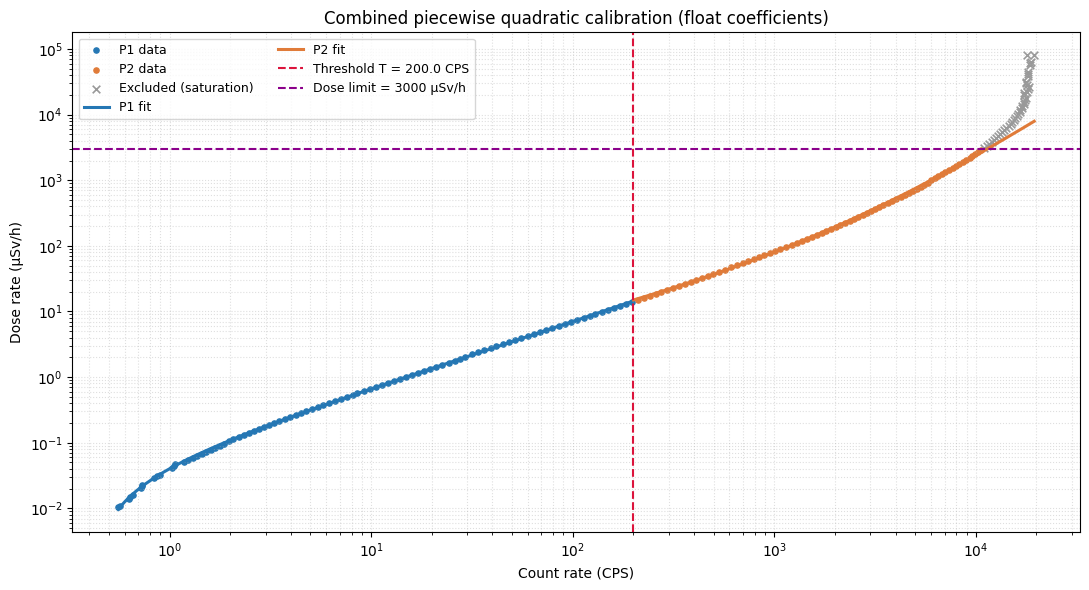

In [20]:
# Dense evaluation grid spanning the full CPS range (log-spaced)
x_full = np.geomspace(x[x > 0].min(), x.max(), 600)
y_full = np.where(
    x_full <= threshold,
    np.polyval(p1, x_full),
    np.polyval(p2, x_full),
)

fig, ax = plt.subplots(figsize=(11, 6))

# Data
ax.scatter(x[low],      y[low],      s=14, color=C_P1,   label="P1 data")
ax.scatter(x[high],     y[high],     s=14, color=C_P2,   label="P2 data")
ax.scatter(x[excluded], y[excluded], s=30, color=C_EXCL,  marker="x", linewidths=1.2,
           label="Excluded (saturation)")

# Fitted curves
mask1 = x_full <= threshold
mask2 = x_full >  threshold
ax.plot(x_full[mask1], y_full[mask1], color=C_P1, lw=2.2, label="P1 fit")
ax.plot(x_full[mask2], y_full[mask2], color=C_P2, lw=2.2, label="P2 fit")

# Reference lines
ax.axvline(threshold,  color=C_TH, lw=1.5, ls="--", label=f"Threshold T = {threshold:.1f} CPS")
ax.axhline(DOSE_LIMIT, color=C_DL, lw=1.5, ls="--", label=f"Dose limit = {DOSE_LIMIT:.0f} µSv/h")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Count rate (CPS)")
ax.set_ylabel("Dose rate (µSv/h)")
ax.set_title("Combined piecewise quadratic calibration (float coefficients)")
ax.legend(fontsize=9, ncol=2, loc="upper left")
ax.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()
plt.show()

## Step 7 – Encode coefficients to int16 holding registers

Modbus holding registers are 16-bit integers.  To store a floating-point
coefficient, the firmware uses a **(mantissa, exponent)** pair:

$$
a = \underbrace{m}_{\in\,[-32000,\;32000]} \;\times\; 10^{\,\underbrace{e}_{\in\,[-9,\;9]}}
$$

The threshold is encoded the same way: $T = m_T \times 10^{e_T}$.

This gives **14 holding registers** total (7 values × 2 registers each).
The encoding algorithm picks the exponent that maximises the number of
significant digits in the mantissa.

In [21]:
registers = fit_piecewise_quadratic(x, y, threshold_cps=THRESHOLD_CPS, dose_limit=DOSE_LIMIT)

# Build a readable table comparing float vs encoded values
_ROWS = [
    ("P1 a\u2082",     "scale_coeff_p1_a2", "scale_exp_p1_a2", p1[0]),
    ("P1 a\u2081",     "scale_coeff_p1_a1", "scale_exp_p1_a1", p1[1]),
    ("P1 a\u2080",     "scale_coeff_p1_a0", "scale_exp_p1_a0", p1[2]),
    ("Threshold", "scale_coeff_th",    "scale_exp_th",    threshold),
    ("P2 a\u2082",     "scale_coeff_p2_a2", "scale_exp_p2_a2", p2[0]),
    ("P2 a\u2081",     "scale_coeff_p2_a1", "scale_exp_p2_a1", p2[1]),
    ("P2 a\u2080",     "scale_coeff_p2_a0", "scale_exp_p2_a0", p2[2]),
]

hdr = f"{'Coeff':<12}  {'Float value':>20}  {'Mantissa':>10}  {'Exp':>4}  {'Decoded':>20}  {'Quant. err':>11}"
print(hdr)
print("\u2500" * len(hdr))
for label, cr, er, fval in _ROWS:
    m       = registers[cr]
    e       = registers[er]
    decoded = decode_mantissa_exp(m, e)
    err_pct = (decoded - fval) / fval * 100 if fval != 0.0 else 0.0
    print(f"{label:<12}  {fval:>+20.10e}  {m:>10}  {e:>4}  {decoded:>+20.10e}  {err_pct:>+10.4f}%")

Coeff                  Float value    Mantissa   Exp               Decoded   Quant. err
───────────────────────────────────────────────────────────────────────────────────────
P1 a₂            +1.8149119338e-05       18149    -9     +1.8149000000e-05     -0.0007%
P1 a₁            +6.8783884542e-02        6878    -5     +6.8780000000e-02     -0.0056%
P1 a₀            -2.8622736000e-02      -28623    -6     -2.8623000000e-02     +0.0009%
Threshold        +2.0000000000e+02       20000    -2     +2.0000000000e+02     +0.0000%
P2 a₂            +1.7732208492e-05       17732    -9     +1.7732000000e-05     -0.0012%
P2 a₁            +6.0292493466e-02        6029    -5     +6.0290000000e-02     -0.0041%
P2 a₀            +2.1827058279e+00       21827    -4     +2.1827000000e+00     -0.0003%


## Step 8 – Verify the firmware reconstruction

The firmware only has access to the integer register values.  Below we
reconstruct the polynomial from the encoded mantissa/exponent pairs and
compare it against the original float fit and the raw data.

In [22]:
# Decode all coefficients from integer registers
def _dec(c, e):
    return decode_mantissa_exp(registers[c], registers[e])

th_enc = _dec("scale_coeff_th", "scale_exp_th")
a2p1   = _dec("scale_coeff_p1_a2", "scale_exp_p1_a2")
a1p1   = _dec("scale_coeff_p1_a1", "scale_exp_p1_a1")
a0p1   = _dec("scale_coeff_p1_a0", "scale_exp_p1_a0")
a2p2   = _dec("scale_coeff_p2_a2", "scale_exp_p2_a2")
a1p2   = _dec("scale_coeff_p2_a1", "scale_exp_p2_a1")
a0p2   = _dec("scale_coeff_p2_a0", "scale_exp_p2_a0")

print("Firmware polynomials (from integer registers):")
print(f"  T  = {th_enc:.4g} CPS")
print(f"  P1 : dose = {a2p1:.6e} · CPS²  +  {a1p1:.6e} · CPS  +  {a0p1:.6e}")
print(f"  P2 : dose = {a2p2:.6e} · CPS²  +  {a1p2:.6e} · CPS  +  {a0p2:.6e}")

# Evaluate firmware reconstruction on dense grid
y_fw = np.where(
    x_full <= th_enc,
    a2p1 * x_full**2 + a1p1 * x_full + a0p1,
    a2p2 * x_full**2 + a1p2 * x_full + a0p2,
)

# Firmware reconstruction at data points (for residuals)
y_fw_at_data = np.where(
    x <= th_enc,
    a2p1 * x**2 + a1p1 * x + a0p1,
    a2p2 * x**2 + a1p2 * x + a0p2,
)
used = low | high
rel_err_pct = (y_fw_at_data[used] - y[used]) / y[used] * 100

# Fit quality metrics
quality = fit_residuals(x, y, registers, dose_limit=DOSE_LIMIT)
print(f"\nFit quality (int-encoded vs. data):")
print(f"  RMSE        : {quality['rmse']:.4g} µSv/h")
print(f"  Max |error| : {quality['max_abs_err']:.4g} µSv/h")

Firmware polynomials (from integer registers):
  T  = 200 CPS
  P1 : dose = 1.814900e-05 · CPS²  +  6.878000e-02 · CPS  +  -2.862300e-02
  P2 : dose = 1.773200e-05 · CPS²  +  6.029000e-02 · CPS  +  2.182700e+00

Fit quality (int-encoded vs. data):
  RMSE        : 28.22 µSv/h
  Max |error| : 242.7 µSv/h


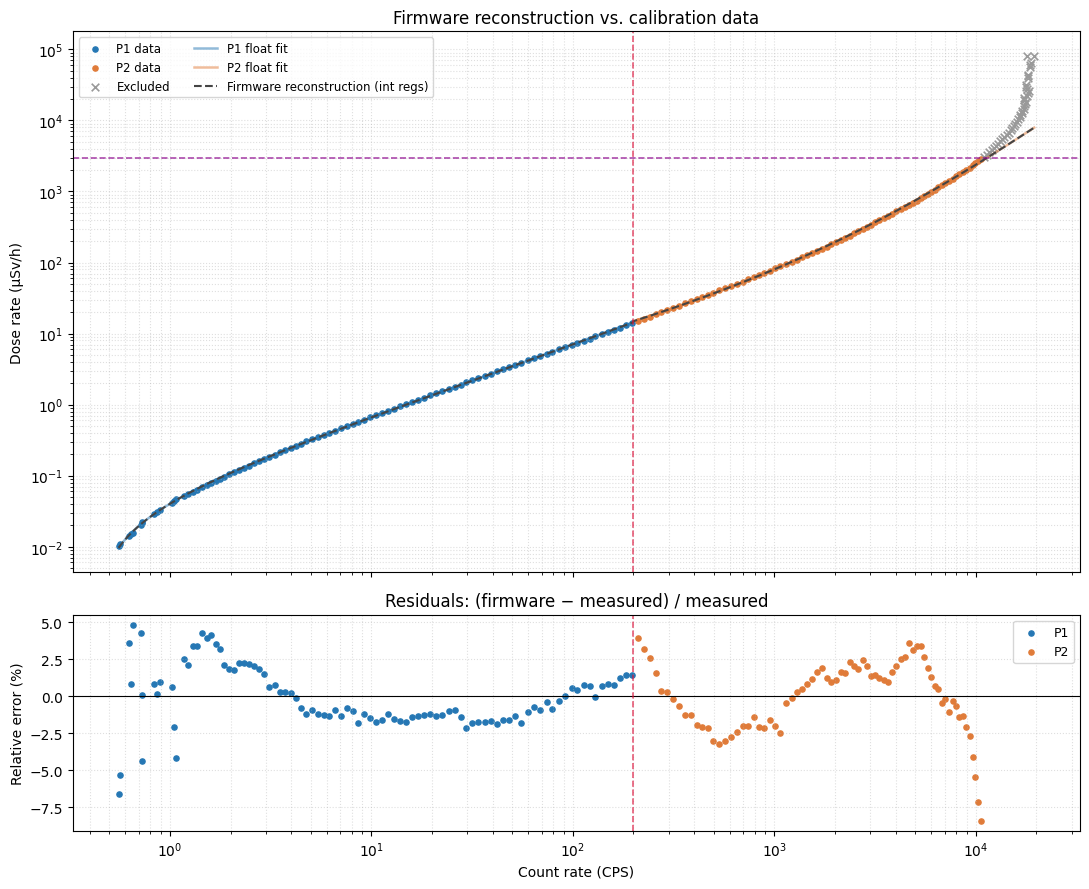

Saved: calibration_diagnostics.png


In [23]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 9),
                                      gridspec_kw={"height_ratios": [2.5, 1]},
                                      sharex=True)

# ── Top panel: fit overlay ─────────────────────────────────────────────────────
ax_top.scatter(x[low],      y[low],      s=14, color=C_P1,  label="P1 data")
ax_top.scatter(x[high],     y[high],     s=14, color=C_P2,  label="P2 data")
ax_top.scatter(x[excluded], y[excluded], s=30, color=C_EXCL, marker="x", linewidths=1.2,
               label="Excluded")

fw_mask1 = x_full <= th_enc
fw_mask2 = x_full >  th_enc
ax_top.plot(x_full[mask1], y_full[mask1], color=C_P1, lw=1.8, alpha=0.5, label="P1 float fit")
ax_top.plot(x_full[mask2], y_full[mask2], color=C_P2, lw=1.8, alpha=0.5, label="P2 float fit")
ax_top.plot(x_full, y_fw, color=C_FW, lw=1.5, ls="--", label="Firmware reconstruction (int regs)")

ax_top.axvline(threshold, color=C_TH, lw=1.2, ls="--", alpha=0.7)
ax_top.axhline(DOSE_LIMIT, color=C_DL, lw=1.2, ls="--", alpha=0.7)

ax_top.set_xscale("log")
ax_top.set_yscale("log")
ax_top.set_ylabel("Dose rate (µSv/h)")
ax_top.set_title("Firmware reconstruction vs. calibration data")
ax_top.legend(fontsize=8.5, ncol=2, loc="upper left")
ax_top.grid(True, which="both", ls=":", alpha=0.4)

# ── Bottom panel: relative residuals ───────────────────────────────────────────
ax_bot.scatter(x[used][x[used] <= threshold], rel_err_pct[x[used] <= threshold],
               s=14, color=C_P1, label="P1")
ax_bot.scatter(x[used][x[used] >  threshold], rel_err_pct[x[used] >  threshold],
               s=14, color=C_P2, label="P2")
ax_bot.axhline(0, color="black", lw=0.8)
ax_bot.axvline(threshold, color=C_TH, lw=1.2, ls="--", alpha=0.7)
ax_bot.set_xscale("log")
ax_bot.set_xlabel("Count rate (CPS)")
ax_bot.set_ylabel("Relative error (%)")
ax_bot.set_title("Residuals: (firmware − measured) / measured")
ax_bot.legend(fontsize=9)
ax_bot.grid(True, which="both", ls=":", alpha=0.4)

plt.tight_layout()
plt.savefig("calibration_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: calibration_diagnostics.png")

## Optional – Apply to device

Uncomment the cell below to write the calibration registers to a
connected Geiger device.

In [24]:
# from nlab_modbus.services.manager import DeviceManager
# from nlab_modbus.core.enums import DeviceType
# from nlab_modbus.calibration import apply_calibration
#
# HOST      = "192.168.10.34"
# PORT      = 5002
# DEVICE_ID = 2
#
# mgr    = DeviceManager()
# device = mgr.connect_remote(HOST, PORT, DEVICE_ID, DeviceType.GEIGER)
#
# written = apply_calibration(
#     device,
#     path=CSV_PATH,
#     threshold_cps=THRESHOLD_CPS,
# )
# print(f"Wrote {len(written)} registers to device {DEVICE_ID}.")
#
# mgr.close_all()